In [3]:
!pip install numpy
!pip install pandas
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 5.2 MB/s  0:00:02m 5.3 MB/s eta 0:00:01
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 6.6 MB/s  0:00:01m 5.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 9.7 MB/s  0:00:00m 11.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.2 MB/s  0:00:0010.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("botsient_kysitlus.csv")
data.head()

,KOOD,SUGU,VERSIOON,MOTT,ENETOHU[PEEG],ENETOHU[TAPSUS],ENETOHU[NIME],ENETOHU[NORM],ENETOHU[RAAM],ENETOHU[KUSIMUS],ENETOHU[INFO],AREVUS[AREV1],AREVUS[AREV2],AREVUS[AREV3],AREVUS[AREV4],TEADLIK[TEAD1],TEADLIK[TEAD2],TEADLIK[TEAD3]
0,Pätu,Naine,Sessioonõppes,9,4,4,3,4,3,4,3,10 (väga),10 (väga),10 (väga),8,4,7,3
1,Nellykas,Naine,Päevaõppes,8,7,7,6,6,6,7,6,5,7,7,6,7,7,6
2,ROOSAPANTER99,Naine,Sessioonõppes,10 (väga),7,6,5,5,7,7,4,6,8,10 (väga),8,7,10 (täielikult),8
3,monstercollu,Naine,Päevaõppes,10 (väga),8,8,6,8,7,6,7,7,7,7,5,7,9,7
4,armastuspäästabmaailma,Naine,Sessioonõppes,10 (väga),8,8,8,6,8,4,3,8,8,8,8,6,5,6


In [17]:
data = data.drop_duplicates(subset="KOOD", keep="last")
data.describe()

,KOOD,SUGU,VERSIOON,MOTT,ENETOHU[PEEG],ENETOHU[TAPSUS],ENETOHU[NIME],ENETOHU[NORM],ENETOHU[RAAM],ENETOHU[KUSIMUS],ENETOHU[INFO],AREVUS[AREV1],AREVUS[AREV2],AREVUS[AREV3],AREVUS[AREV4],TEADLIK[TEAD1],TEADLIK[TEAD2],TEADLIK[TEAD3]
count,154,154,154,154,154,154,154,154,154,154,154,154,154,154,154,154,154,154
unique,154,3,2,6,10,9,10,10,10,10,10,10,10,10,10,10,10,10
top,Pätu,Naine,Päevaõppes,10 (väga),7,8,5,6,6,6,5,9,8,9,8,7,7,5
freq,1,145,87,56,37,35,44,34,37,33,34,32,30,32,27,41,38,40


In [20]:
data["ENETOHU[PEEG]"].unique()

array(['4', '7', '8', '5', '9', '6', '2', '3', '10 (väga)',
       '1 (üldse mitte)'], dtype=object)

In [22]:
data.columns

Index(['KOOD', 'SUGU', 'VERSIOON', 'MOTT', 'ENETOHU[PEEG]', 'ENETOHU[TAPSUS]',
       'ENETOHU[NIME]', 'ENETOHU[NORM]', 'ENETOHU[RAAM]', 'ENETOHU[KUSIMUS]',
       'ENETOHU[INFO]', 'AREVUS[AREV1]', 'AREVUS[AREV2]', 'AREVUS[AREV3]',
       'AREVUS[AREV4]', 'TEADLIK[TEAD1]', 'TEADLIK[TEAD2]', 'TEADLIK[TEAD3]'],
      dtype='object')

In [27]:
cols = [col for col in data.columns if col not in ["KOOD", "SUGU", "VERSIOON"]]

for col in cols:
    data[col] = pd.to_numeric(
        data[col].astype(str).str.split("(").str[0].str.strip()
    )

In [28]:
data.head()

,KOOD,SUGU,VERSIOON,MOTT,ENETOHU[PEEG],ENETOHU[TAPSUS],ENETOHU[NIME],ENETOHU[NORM],ENETOHU[RAAM],ENETOHU[KUSIMUS],ENETOHU[INFO],AREVUS[AREV1],AREVUS[AREV2],AREVUS[AREV3],AREVUS[AREV4],TEADLIK[TEAD1],TEADLIK[TEAD2],TEADLIK[TEAD3]
0,Pätu,Naine,Sessioonõppes,9,4,4,3,4,3,4,3,10,10,10,8,4,7,3
1,Nellykas,Naine,Päevaõppes,8,7,7,6,6,6,7,6,5,7,7,6,7,7,6
2,ROOSAPANTER99,Naine,Sessioonõppes,10,7,6,5,5,7,7,4,6,8,10,8,7,10,8
3,monstercollu,Naine,Päevaõppes,10,8,8,6,8,7,6,7,7,7,7,5,7,9,7
4,armastuspäästabmaailma,Naine,Sessioonõppes,10,8,8,8,6,8,4,3,8,8,8,8,6,5,6


In [33]:
groups = {
    "ENETOHU": [col for col in data.columns if col.startswith("ENETOHU")],
    "AREVUS": [col for col in data.columns if col.startswith("AREVUS")],
    "TEADLIK": [col for col in data.columns if col.startswith("TEADLIK")]
}

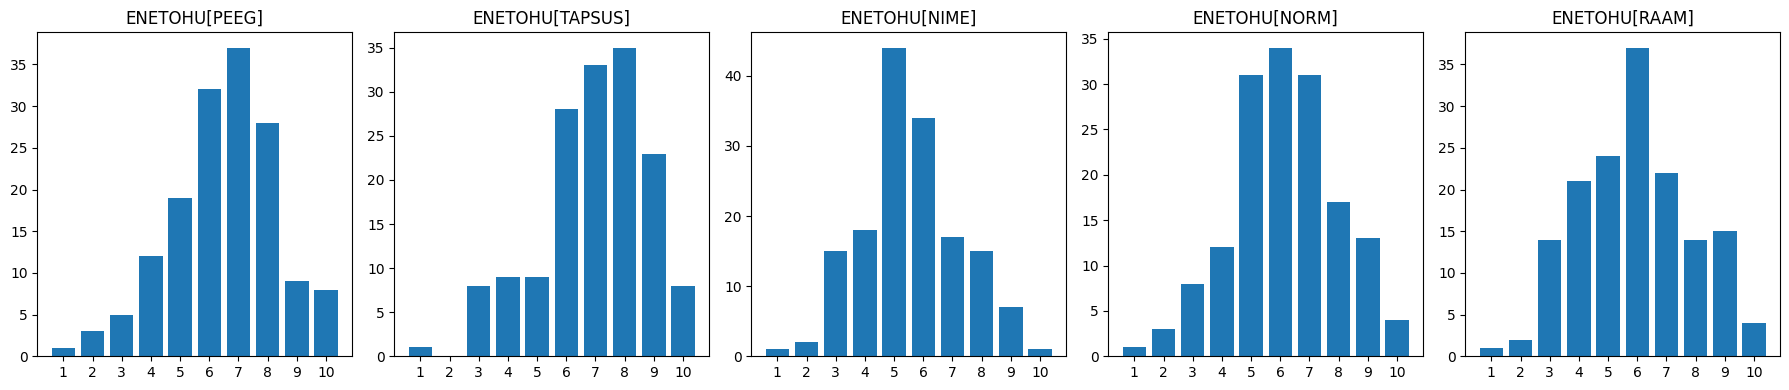

In [40]:
# ENETOHU
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, [col for col in data.columns if col.startswith("ENETOHU")]):
    counts = data[col].value_counts().reindex(range(1, 11), fill_value=0)
    bars = ax.bar(range(1, 11), counts, width=0.8)

    ax.set_xticks(range(1, 11))
    ax.set_title(col)

plt.tight_layout()
plt.show()

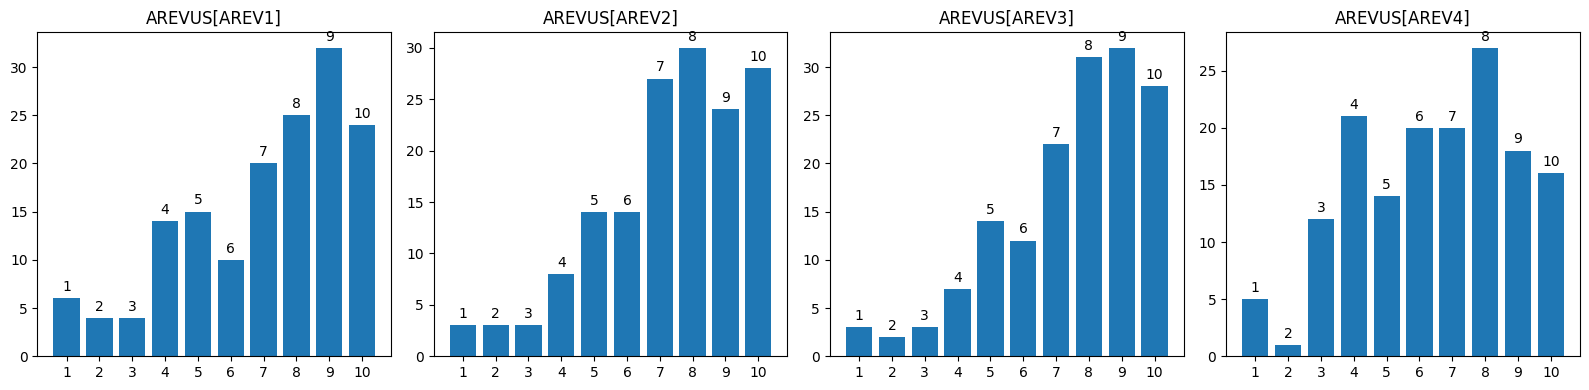

In [41]:
# AREVUS
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, [col for col in data.columns if col.startswith("AREVUS")]):
    counts = data[col].value_counts().reindex(range(1, 11), fill_value=0)
    bars = ax.bar(range(1, 11), counts, width=0.8)

    ax.bar_label(bars, labels=[str(i) for i in range(1, 11)], padding=3)
    ax.set_xticks(range(1, 11))
    ax.set_title(col)

plt.tight_layout()
plt.show()

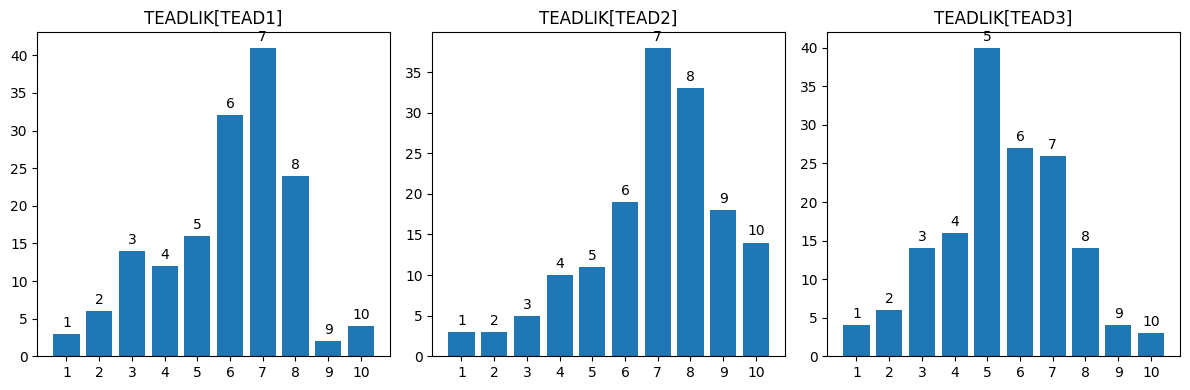

In [42]:
# TEADLIK
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, [col for col in data.columns if col.startswith("TEADLIK")]):
    counts = data[col].value_counts().reindex(range(1, 11), fill_value=0)
    bars = ax.bar(range(1, 11), counts, width=0.8)

    ax.bar_label(bars, labels=[str(i) for i in range(1, 11)], padding=3)
    ax.set_xticks(range(1, 11))
    ax.set_title(col)

plt.tight_layout()
plt.show()